# 5. Risk analysis and the combined portfolio

1. **Validation**: our Strategy A vs the Lustig-Roussanov-Verdelhan developed carry factor (course file `CurrencyPortfolios.xls`, put it in `data/raw/`).
2. **Strategy A risk**: exposure to volatility shocks and the dollar factor, worst months, the 2008 crash.
3. **Strategy C risk**: beta to BTC, P&L by coin, a pre-specified risk control.
4. **Combined portfolio**: A and C each scaled to 10% volatility, 50/50.

Same functions as `code/05_risk_analysis.py`. Run notebooks 2 and 4 (or the scripts) first so `output/` is up to date.

## What this notebook does

**Purpose.** Analyse when the two strategies lose money, check Strategy A against the academic carry factor, test one risk control for Strategy C, and combine the two strategies. Same functions as `code/05_risk_analysis.py`.

**Data**
- `output/strategyA/monthly_returns.csv` (notebook 02) and the crypto data in `data/clean/` (notebook 03);
- the course file `CurrencyPortfolios.xls` (Lustig, Roussanov & Verdelhan currency portfolios), placed in `data/raw/`. It provides the developed-country carry factor (HML), the dollar factor (RX) and changes in aggregate equity volatility, monthly to 2021-05.

**Steps**
1. **Validation.** Compare Strategy A with the LRV developed HML factor over the months they overlap.
2. **Strategy A risk.** Regress monthly net carry on the dollar factor and volatility changes (Newey-West t-statistics, 3 lags); list the worst months and the 2008 crash.
3. **Strategy C risk.** Beta to BTC (daily, Newey-West, 7 lags), P&L by coin, worst weeks, and a **pre-specified risk control**: cap each coin at 1/6 of its leg and do not hold as a long any coin whose 7-day funding is below -50% a year.
4. **Combined portfolio.** Scale A and C each to 10% volatility using only past volatility (36 months for A, 12 for C), then combine 50/50.

**Outputs** in `output/risk/`: the tables shown here and `combined_portfolio.png`.

In [1]:
# Setup: run everything from the project root so the scripts' relative paths work
import os, importlib.util
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

def load_script(path, name):
    """Import a numbered script from code/ (file names starting with a digit can't be imported normally)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

Working directory: /Users/reza/Desktop/mfe-term_3/currency_market/currency-crypto-carry


In [2]:
R = load_script("code/05_risk_analysis.py", "risk")
print("CurrencyPortfolios.xls found:", R.XLS.exists())

CurrencyPortfolios.xls found: True


## Part 1 and 2 - Strategy A: validation and risk exposures
This prints the comparison with the LRV carry factor, Newey-West regressions, worst months and the 2008 crash.

In [3]:
carry_a = R.strategy_a()

=== 1. STRATEGY A vs LUSTIG-ROUSSANOV-VERDELHAN DEVELOPED HML (net) ===
                           Start      End Months Ann. mean (%) Ann. vol (%)    Sharpe Max drawdown (%)  Skewness Worst month (%)  Correlation
Strategy A carry (net)   1999-05  2021-05    264      3.215618     9.496824  0.338599        -37.00107 -0.463667      -12.036567        0.818
LRV developed HML (net)  1999-05  2021-05    264      2.343063     10.04318  0.233299       -39.169897 -0.308658      -13.778988        0.818

=== 2. STRATEGY A RISK EXPOSURES (monthly net carry, Newey-West t-stats) ===
                                         coef  NW t-stat
model                    term                           
RX (dollar)              const          0.003      1.640
                         RX (dollar)    0.415      4.416
                         R2             0.123        NaN
                         N            264.000        NaN
dVol (LRV)               const          0.003      1.601
                         

## Part 3 - Strategy C risk and the pre-specified risk control
Control (fixed before running it): cap each coin at 1/6 of its leg, and do not hold as a long any coin whose 7-day funding is below -50% a year.

In [4]:
C = R.load_strategy_c()
base, ctrl = R.strategy_c(C)


(USDC sanity check: price range 0.9845 to 1.0017)



=== 3. STRATEGY C BETA TO BTC (daily net returns, Newey-West t-stats) ===
                                 coef  NW t-stat
strategy        term                            
Base            const          0.0001     0.3823
                BTC return    -0.0182    -0.7545
                R2             0.0014        NaN
                N           2402.0000        NaN
Risk-controlled const         -0.0000    -0.2878
                BTC return    -0.0093    -0.8261
                R2             0.0016        NaN
                N           2402.0000        NaN
  on BTC's worst 5% days: base avg 0.14%, BTC avg -7.15%



=== STRATEGY C P&L CONTRIBUTION BY COIN (base, sum of daily % pts) ===
      total P&L (% pts)  price (% pts)  funding (% pts)  days long  days short  worst day (% pts)
LUNA              -87.0          -90.6              3.6        166         189              -14.6
XRP               -58.2          -65.4              7.3        567         742               -9.4
DOGE              -43.5          -46.3              2.8        343         785               -7.5
FTT               -12.5          -20.7              8.2        114          56              -12.4
LTC                -7.6          -10.9              3.4        273         904               -6.7
ETH                -6.8           -8.7              1.9        483         707               -4.4
BTC                 9.7           12.6             -2.9        644         652               -2.4
LINK               27.2           20.5              6.7        343        1225              -11.9
ADA                31.9           26.8        

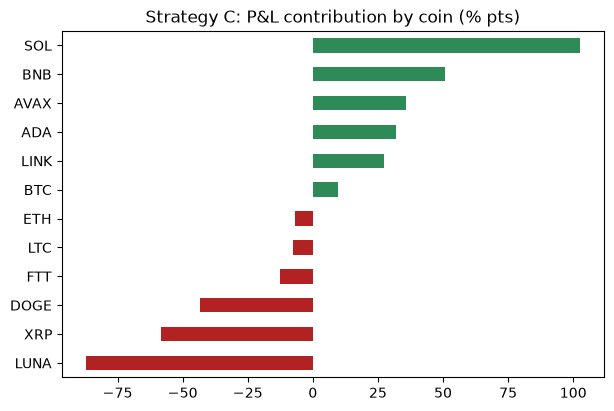

In [5]:
contrib = pd.read_csv("output/risk/C_contribution_by_coin.csv", index_col=0)["total P&L (% pts)"]
contrib.plot.barh(figsize=(7, 4.5), color=["firebrick" if v < 0 else "seagreen" for v in contrib],
                  title="Strategy C: P&L contribution by coin (% pts)"); plt.show()

## Part 4 - combined portfolio


=== 4. COMBINED PORTFOLIO (each leg scaled to 10% vol with lagged vol, 50/50) ===
                  Start      End Months Ann. mean (%) Ann. vol (%)    Sharpe Max drawdown (%)  Skewness Worst month (%)
A (10% vol)     2021-02  2026-08     67      6.699216     9.430257  0.710396       -10.962499 -0.508362       -7.375592
C (10% vol)     2021-02  2026-08     67      0.436368     9.277791  0.047034       -21.426103 -0.825125      -10.178191
Combined 50/50  2021-02  2026-08     67      3.567792     6.962494   0.51243       -10.619252 -0.487811       -5.938938
  correlation A vs C (scaled, overlap): 0.108


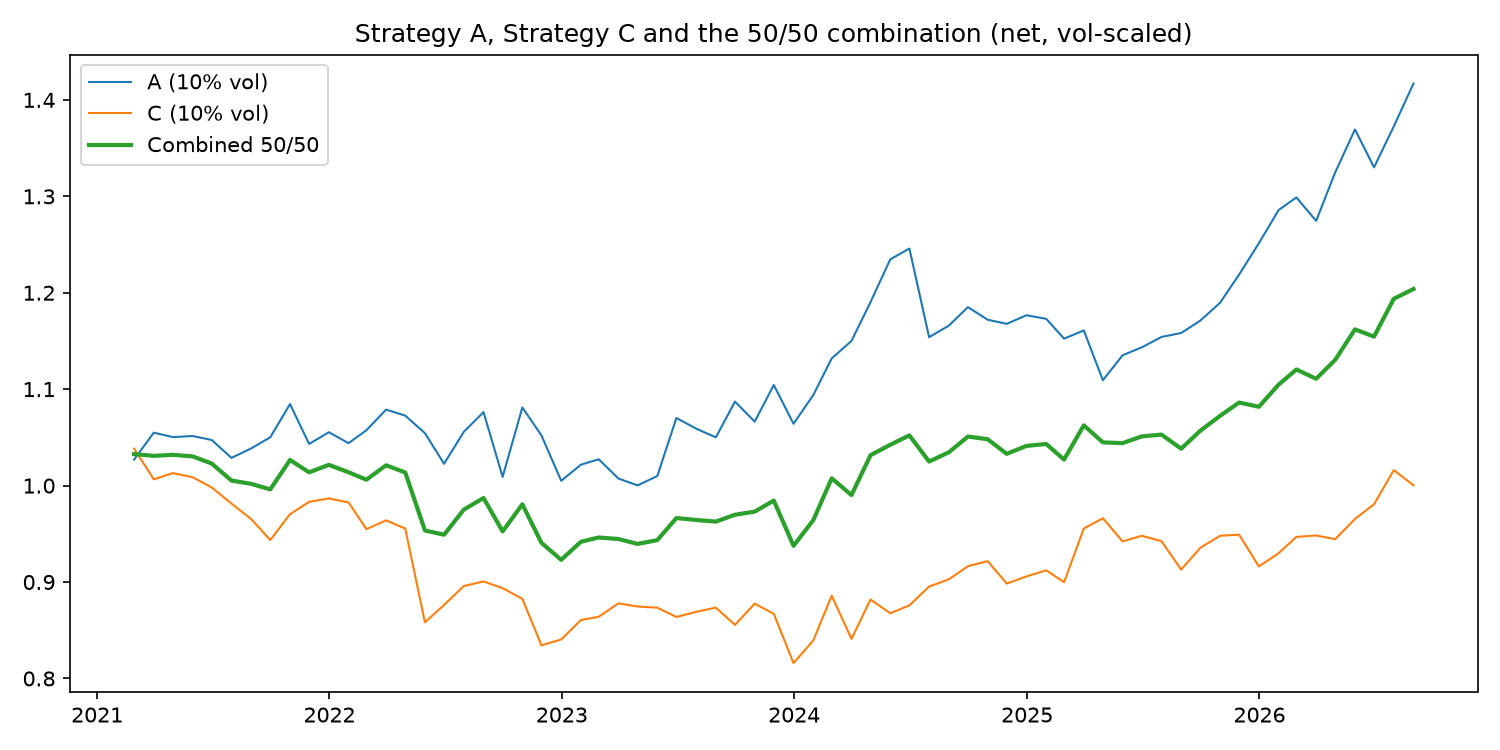

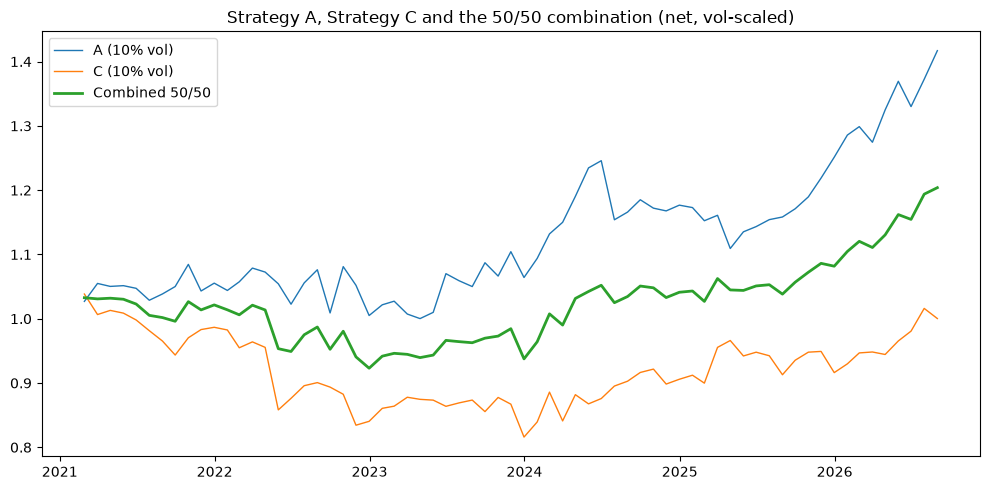

In [6]:
R.combined(carry_a, base["net"])
display(Image("output/risk/combined_portfolio.png"))

### Take-aways
- Strategy A tracks the academic carry factor and loses when volatility spikes (the classic carry-crash exposure).
- Strategy C is market-neutral (no BTC beta); its losses come from single coins that collapsed (LUNA, FTT) or rallied while shorted.
- The pre-specified risk control did not improve the Sharpe ratio; we report it as is.
- FX and crypto carry are nearly uncorrelated, so combining them reduces volatility.

## Questions this notebook answers, and results

**1. Is our Strategy A a proper carry trade?** Yes. Over 1999-05 to 2021-05 (264 months), its monthly net returns have a **0.82 correlation** with the LRV developed carry factor. Ours: 3.2% a year, Sharpe 0.34; LRV: 2.3% a year, Sharpe 0.23; both have about a -37% to -39% maximum drawdown.

**2. When does Strategy A lose money?** When volatility spikes. With both factors in the regression, the beta to equity-volatility changes is **-1.55 (t = -3.7)** and to the dollar factor **0.35 (t = 4.1)**; R² is 0.18 and the remaining alpha (0.25% a month, t = 1.7) is not significant. The worst months are 2008-10 (-12.0%), 2007-08 (-7.8%), 2000-05 (-7.0%), 2009-01 (-6.8%), 2008-03 (-6.5%) and 2015-01 (-6.4%, the Swiss franc de-peg). From July 2008 to March 2009 it lost **-20.5%**.

**3. Is Strategy C exposed to the crypto market?** No. Its beta to BTC is -0.018 (t = -0.75). On BTC's worst 5% of days (BTC -7.2% on average) it made +0.14% on average. Its risk is coin-specific. P&L contributions (sum of daily % points): LUNA -87, XRP -58, DOGE -44, FTT -13, LTC -8, ETH -7; SOL +102, BNB +51, AVAX +36, ADA +32, LINK +27, BTC +10.

**4. Does the pre-specified risk control help?** No.
- Full-sample net Sharpe falls from 0.14 to -0.16; out-of-sample from 0.81 to 0.74.
- It does cut losses (maximum drawdown -43% vs -67%; LUNA week -18.9% vs -27.3%), but mostly because the 1/6 cap leaves about half the capital unused (average exposure 0.49).
- LUNA's funding fell below -50% a year only on 2022-05-10, mid-week, after the Sunday rebalance, so the filter came too late.
- The filter also blocked BNB (109 days) and SOL (72 days), the two biggest winners.
- Lesson: in crypto, deeply negative funding usually signals crowded *shorts*, not a coin in distress.

**5. Does combining the strategies help?** Over 2021-02 to 2026-08 (67 months), each scaled to 10% volatility: A has Sharpe 0.71, C 0.05, and the 50/50 mix **0.51** with only 7.0% volatility and a -10.6% maximum drawdown. The correlation between A and C is **0.11**, so combining them reduces risk, but C was weak in this window.

**Limitations**
- The LRV data and its volatility series end in 2021-05, so the factor regressions cover 1999-2021 only (a hand-saved FRED VIXCLS file would extend them).
- Only one risk control was tested, by design, to avoid tuning on the results.
- The combined-portfolio window is short (67 months).